# Comparación de modelos de machine learning para la predicción de cáncer de pulmón

## Importación de librerías y modelos

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, roc_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
import optuna
import shap
import joblib
import json

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

# Rutas de la carpeta que guardan los gráficos
output_dir = "resultadosML"
eda_dir = "distribucionDatos"
export_dir = "exported_best_model"

os.makedirs(output_dir, exist_ok=True)
os.makedirs(eda_dir, exist_ok=True)
os.makedirs(export_dir, exist_ok=True)

print("Librerías importadas correctamente")

Librerías importadas correctamente


## Dataset y verificación de datos

### Carga de Dataset

In [2]:
DATA_PATH = "data/dataset.csv"

df = pd.read_csv(DATA_PATH, sep=";")
print(f"Datos: {df.shape[0]} filas y {df.shape[1]} columnas")
df.head()

Datos: 5000 filas y 18 columnas


,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE,PULMONARY_DISEASE
0,68,1,1,1,1,1,0,57.831178,0,0,1,1,95.977287,1,0,0,0,NO
1,81,1,1,0,0,1,1,47.694835,1,1,0,1,97.184483,0,0,0,0,YES
2,58,1,1,0,0,0,0,59.577435,0,1,1,0,94.974939,0,0,0,0,NO
3,44,0,1,0,1,1,0,59.785767,0,1,0,1,95.187900,0,0,0,0,YES
4,72,0,1,1,1,1,1,59.733941,0,1,0,1,93.503008,0,0,0,0,YES


### Información del Dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   AGE                     5000 non-null   int64  
 1   GENDER                  5000 non-null   int64  
 2   SMOKING                 5000 non-null   int64  
 3   FINGER_DISCOLORATION    5000 non-null   int64  
 4   MENTAL_STRESS           5000 non-null   int64  
 5   EXPOSURE_TO_POLLUTION   5000 non-null   int64  
 6   LONG_TERM_ILLNESS       5000 non-null   int64  
 7   ENERGY_LEVEL            5000 non-null   float64
 8   IMMUNE_WEAKNESS         5000 non-null   int64  
 9   BREATHING_ISSUE         5000 non-null   int64  
 10  ALCOHOL_CONSUMPTION     5000 non-null   int64  
 11  THROAT_DISCOMFORT       5000 non-null   int64  
 12  OXYGEN_SATURATION       5000 non-null   float64
 13  CHEST_TIGHTNESS         5000 non-null   int64  
 14  FAMILY_HISTORY          5000 non-null   int64  
 15

In [4]:
df.describe()

,AGE,GENDER,SMOKING,FINGER_DISCOLORATION,MENTAL_STRESS,EXPOSURE_TO_POLLUTION,LONG_TERM_ILLNESS,ENERGY_LEVEL,IMMUNE_WEAKNESS,BREATHING_ISSUE,ALCOHOL_CONSUMPTION,THROAT_DISCOMFORT,OXYGEN_SATURATION,CHEST_TIGHTNESS,FAMILY_HISTORY,SMOKING_FAMILY_HISTORY,STRESS_IMMUNE
count,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,57.222800,0.501200,0.666400,0.6012,0.539800,0.516000,0.439200,55.032043,0.394800,0.80040,0.354200,0.698200,94.991029,0.600600,0.301800,0.204000,0.209600
std,15.799224,0.500049,0.471546,0.4897,0.498463,0.499794,0.496339,7.913083,0.488857,0.39974,0.478318,0.459085,1.481048,0.489824,0.459085,0.403009,0.407064
min,30.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,23.258308,0.000000,0.00000,0.000000,0.000000,89.923133,0.000000,0.000000,0.000000,0.000000
25%,44.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,49.440685,0.000000,1.00000,0.000000,0.000000,93.973176,0.000000,0.000000,0.000000,0.000000
50%,57.000000,1.000000,1.000000,1.0000,1.000000,1.000000,0.000000,55.050421,0.000000,1.00000,0.000000,1.000000,94.974073,1.000000,0.000000,0.000000,0.000000
75%,71.000000,1.000000,1.000000,1.0000,1.000000,1.000000,1.000000,60.323320,1.000000,1.00000,1.000000,1.000000,95.989272,1.000000,1.000000,0.000000,0.000000
max,84.000000,1.000000,1.000000,1.0000,1.000000,1.000000,1.000000,83.046971,1.000000,1.00000,1.000000,1.000000,99.795786,1.000000,1.000000,1.000000,1.000000


In [5]:
print("\nValores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
AGE                       0
GENDER                    0
SMOKING                   0
FINGER_DISCOLORATION      0
MENTAL_STRESS             0
EXPOSURE_TO_POLLUTION     0
LONG_TERM_ILLNESS         0
ENERGY_LEVEL              0
IMMUNE_WEAKNESS           0
BREATHING_ISSUE           0
ALCOHOL_CONSUMPTION       0
THROAT_DISCOMFORT         0
OXYGEN_SATURATION         0
CHEST_TIGHTNESS           0
FAMILY_HISTORY            0
SMOKING_FAMILY_HISTORY    0
STRESS_IMMUNE             0
PULMONARY_DISEASE         0
dtype: int64


## Proceso ETL

### Variable objetivo

In [6]:
target = df.columns[-1]
print(f"\nVariables objetivo: {target}")
print(f"\nValores únicos: {df[target].unique()}")


Variables objetivo: PULMONARY_DISEASE

Valores únicos: <ArrowStringArray>
['NO', 'YES']
Length: 2, dtype: str


### Mapeo de variable objetivo

In [7]:
unique_target = df[target].unique()

if 'Yes' in unique_target and 'No' in unique_target:
  df[target] = df[target].map({'Yes': 1, 'No': 0})
elif 'Positive' in unique_target and 'Negative' in unique_target:
  df[target] = df[target].map({'Positive': 1, 'Negative': 0})
else:
  df[target] = pd.factorize(df[target])[0]

print(f"Distribución de variable objetivo: {df[target].value_counts(normalize=True)}")

Distribución de variable objetivo: PULMONARY_DISEASE
0    0.5926
1    0.4074
Name: proportion, dtype: float64


### Verificación final

In [8]:
print(f"Total de nulos en el dataset: {df.isnull().sum().sum()}")

Total de nulos en el dataset: 0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   AGE                     5000 non-null   int64  
 1   GENDER                  5000 non-null   int64  
 2   SMOKING                 5000 non-null   int64  
 3   FINGER_DISCOLORATION    5000 non-null   int64  
 4   MENTAL_STRESS           5000 non-null   int64  
 5   EXPOSURE_TO_POLLUTION   5000 non-null   int64  
 6   LONG_TERM_ILLNESS       5000 non-null   int64  
 7   ENERGY_LEVEL            5000 non-null   float64
 8   IMMUNE_WEAKNESS         5000 non-null   int64  
 9   BREATHING_ISSUE         5000 non-null   int64  
 10  ALCOHOL_CONSUMPTION     5000 non-null   int64  
 11  THROAT_DISCOMFORT       5000 non-null   int64  
 12  OXYGEN_SATURATION       5000 non-null   float64
 13  CHEST_TIGHTNESS         5000 non-null   int64  
 14  FAMILY_HISTORY          5000 non-null   int64  
 15

### Distribución de valores de cada variable binaria

In [10]:
print(f"Distribución de variable GENDER: {df['GENDER'].value_counts(normalize=True)}")
print(f"\nDistribución de variable SMOKING: {df['SMOKING'].value_counts(normalize=True)}")
print(f"\nDistribución de variable FINGER DISCOLORATION: {df['FINGER_DISCOLORATION'].value_counts(normalize=True)}")
print(f"\nDistribución de variable MENTAL STRESS: {df['MENTAL_STRESS'].value_counts(normalize=True)}")
print(f"\nDistribución de variable EXPOSURE TO POLLUTION: {df['EXPOSURE_TO_POLLUTION'].value_counts(normalize=True)}")

Distribución de variable GENDER: GENDER
1    0.5012
0    0.4988
Name: proportion, dtype: float64

Distribución de variable SMOKING: SMOKING
1    0.6664
0    0.3336
Name: proportion, dtype: float64

Distribución de variable FINGER DISCOLORATION: FINGER_DISCOLORATION
1    0.6012
0    0.3988
Name: proportion, dtype: float64

Distribución de variable MENTAL STRESS: MENTAL_STRESS
1    0.5398
0    0.4602
Name: proportion, dtype: float64

Distribución de variable EXPOSURE TO POLLUTION: EXPOSURE_TO_POLLUTION
1    0.516
0    0.484
Name: proportion, dtype: float64


In [11]:
print(f"\nDistribución de variable LONG TERM ILLNESS: {df['LONG_TERM_ILLNESS'].value_counts(normalize=True)}")
print(f"\nDistribución de variable IMMUNE WEAKNESS: {df['IMMUNE_WEAKNESS'].value_counts(normalize=True)}")
print(f"\nDistribución de variable BREATHING ISSUE: {df['BREATHING_ISSUE'].value_counts(normalize=True)}")
print(f"\nDistribución de variable ALCOHOL CONSUMPTION: {df['ALCOHOL_CONSUMPTION'].value_counts(normalize=True)}")


Distribución de variable LONG TERM ILLNESS: LONG_TERM_ILLNESS
0    0.5608
1    0.4392
Name: proportion, dtype: float64

Distribución de variable IMMUNE WEAKNESS: IMMUNE_WEAKNESS
0    0.6052
1    0.3948
Name: proportion, dtype: float64

Distribución de variable BREATHING ISSUE: BREATHING_ISSUE
1    0.8004
0    0.1996
Name: proportion, dtype: float64

Distribución de variable ALCOHOL CONSUMPTION: ALCOHOL_CONSUMPTION
0    0.6458
1    0.3542
Name: proportion, dtype: float64


In [12]:
print(f"\nDistribución de variable THROAT DISCOMFORT: {df['THROAT_DISCOMFORT'].value_counts(normalize=True)}")
print(f"\nDistribución de variable CHEST TIGHTNESS: {df['CHEST_TIGHTNESS'].value_counts(normalize=True)}")
print(f"\nDistribución de variable FAMILY HISTORY: {df['FAMILY_HISTORY'].value_counts(normalize=True)}")
print(f"\nDistribución de variable SMOKING FAMILY HISTORY: {df['SMOKING_FAMILY_HISTORY'].value_counts(normalize=True)}")
print(f"\nDistribución de variable STRESS_IMMUNE: {df['STRESS_IMMUNE'].value_counts(normalize=True)}")


Distribución de variable THROAT DISCOMFORT: THROAT_DISCOMFORT
1    0.6982
0    0.3018
Name: proportion, dtype: float64

Distribución de variable CHEST TIGHTNESS: CHEST_TIGHTNESS
1    0.6006
0    0.3994
Name: proportion, dtype: float64

Distribución de variable FAMILY HISTORY: FAMILY_HISTORY
0    0.6982
1    0.3018
Name: proportion, dtype: float64

Distribución de variable SMOKING FAMILY HISTORY: SMOKING_FAMILY_HISTORY
0    0.796
1    0.204
Name: proportion, dtype: float64

Distribución de variable STRESS_IMMUNE: STRESS_IMMUNE
0    0.7904
1    0.2096
Name: proportion, dtype: float64


## Análisis exploratorio de datos (EDA)

In [13]:
df_eda = df.copy()
df_eda[target] = df_eda[target].astype(str) # String para las etiquetas

### Histograma de edad

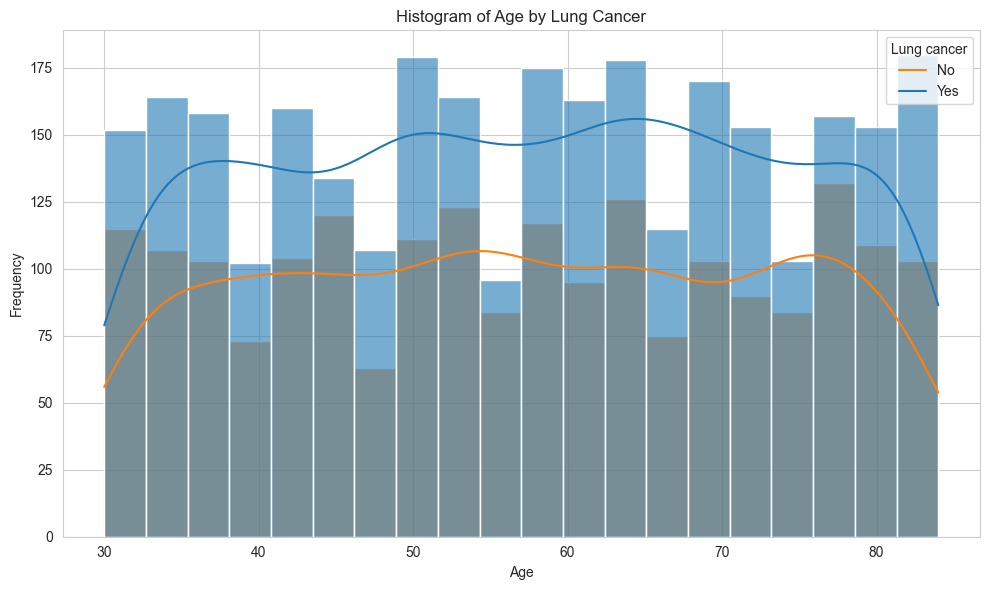

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(data=df_eda, x='AGE', hue=target, kde=True, alpha=0.6, bins=20)
plt.title('Histogram of Age by Lung Cancer')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend(title='Lung cancer', labels=['No','Yes'])
plt.tight_layout()
plt.savefig(os.path.join(eda_dir, 'hist_age_lung_cancer'), dpi=150)
plt.show()

### Gráfico de género

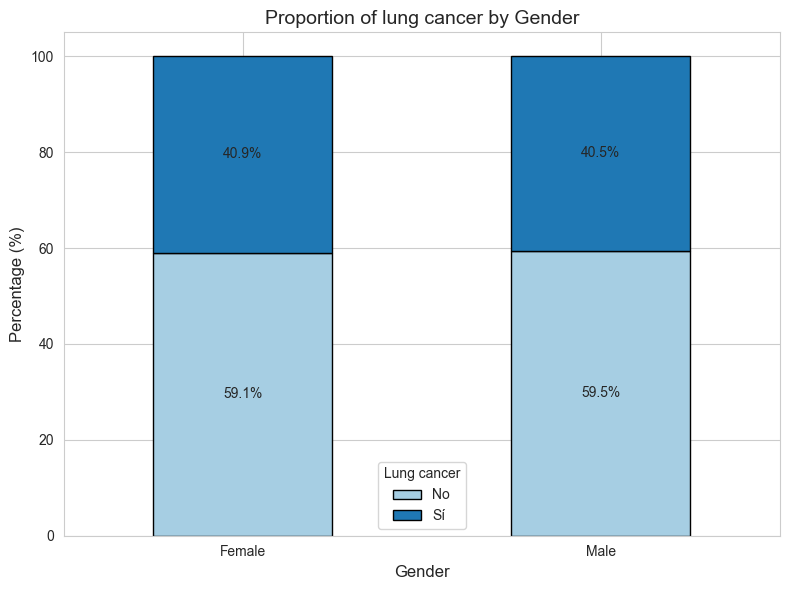

In [15]:
df_plot = df.copy()
df_plot[target] = df_plot[target].map({0: 'No', 1: 'Yes'})
df_plot['GENDER_label'] = df_plot['GENDER'].map({0: 'Female', 1: 'Male'})
df_plot['SMOKING_label'] = df_plot['SMOKING'].map({0: 'No smoker', 1: 'Smoker'})

plt.figure(figsize=(8,6))

# Calcular porcentajes por género
gender_counts = pd.crosstab(df_plot['GENDER_label'], df_plot[target], normalize='index') * 100

gender_counts.plot(
    kind='bar',
    stacked=True,
    color=['#a6cee3', '#1f78b4'],  # celeste claro y azul
    edgecolor='black',
    ax=plt.gca()
)

plt.title('Proportion of lung cancer by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Lung cancer', labels=['No', 'Sí'])

for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(eda_dir, 'gender_lung_cancer.png'), dpi=150)
plt.show()

### Gráfico de tabaquismo

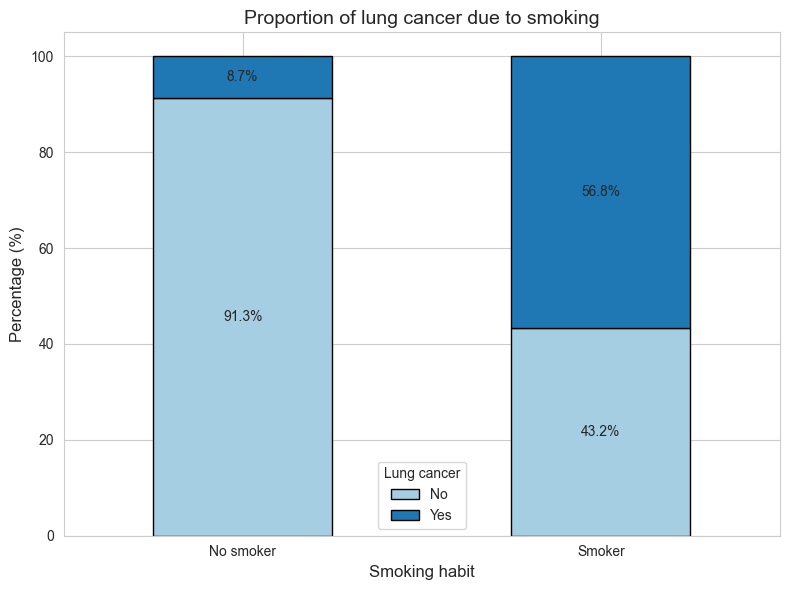

In [16]:
plt.figure(figsize=(8,6))
smoking_counts = pd.crosstab(df_plot['SMOKING_label'], df_plot[target], normalize='index') * 100

smoking_counts.plot(
    kind='bar',
    stacked=True,
    color=['#a6cee3', '#1f78b4'],  # celeste claro y azul
    edgecolor='black',
    ax=plt.gca()
)

plt.title('Proportion of lung cancer due to smoking', fontsize=14)
plt.xlabel('Smoking habit', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Lung cancer', labels=['No', 'Yes'])

for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(eda_dir, 'smoking_lung_cancer.png'), dpi=150)
plt.show()

### Boxplots de variables numéricas

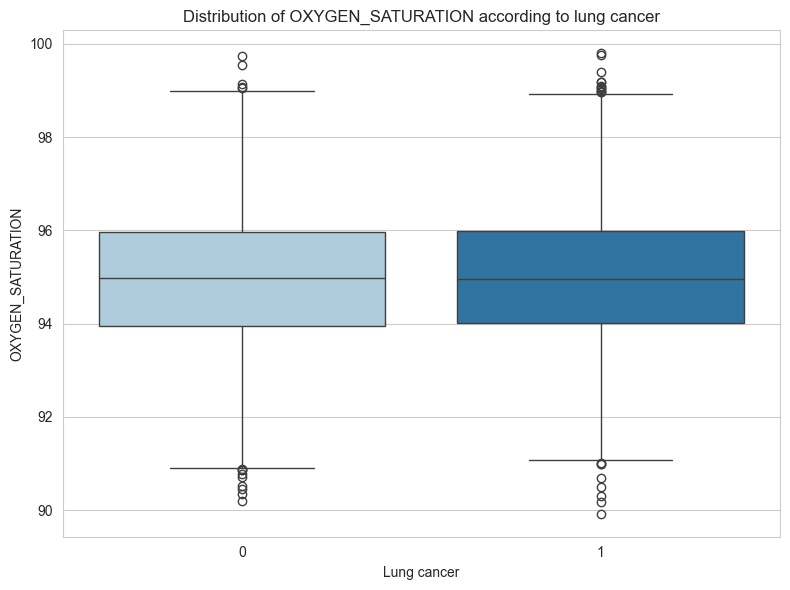

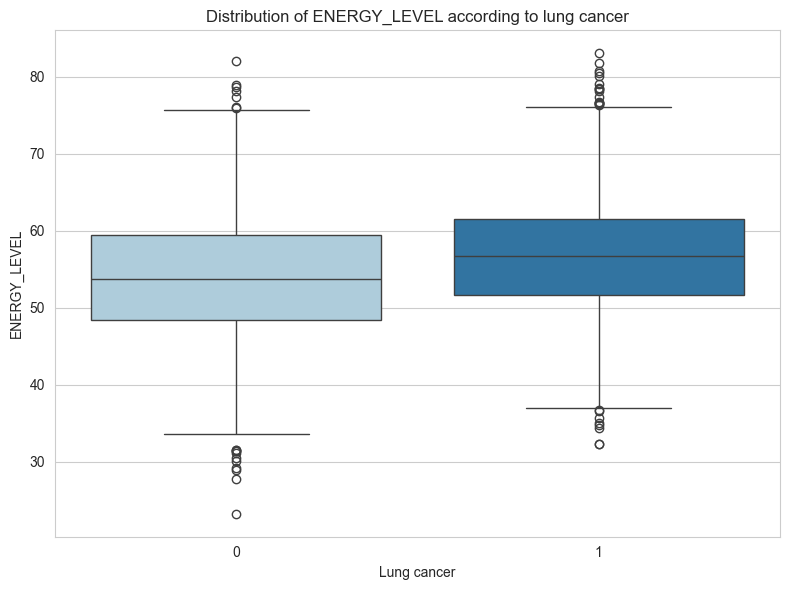

In [17]:
num_vars = ['OXYGEN_SATURATION','ENERGY_LEVEL']

for var in num_vars:
    plt.figure(figsize=(8,6))
    sns.boxplot(
        data=df_eda,
        x=target,
        y=var,
        palette=['#a6cee3', '#1f78b4']  # celeste y azul
    )
    
    plt.title(f'Distribution of {var} according to lung cancer')
    plt.xlabel('Lung cancer')
    plt.ylabel(var)
    
    plt.tight_layout()
    plt.savefig(os.path.join(eda_dir, f'boxplot_{var.lower()}_lung_cancer.png'), dpi=150)
    plt.show()

In [18]:
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")
    return outliers

for col in ['ENERGY_LEVEL', 'OXYGEN_SATURATION']:
    out = detect_outliers_iqr(df, col)
    if len(out) > 0:
        print(out[[col, target]].head())

ENERGY_LEVEL: 31 outliers (0.62%)
      ENERGY_LEVEL  PULMONARY_DISEASE
249      77.325987                  0
441      32.294964                  1
603      83.046971                  1
758      31.117897                  0
1103     78.129695                  0
OXYGEN_SATURATION: 30 outliers (0.60%)
     OXYGEN_SATURATION  PULMONARY_DISEASE
84           90.341484                  0
235          90.312177                  1
451          99.180708                  1
628          90.168116                  1
766          90.870809                  0


En las variables `OXYGEN_SATURATION` y `ENERGY_LEVEL` se detectaron algunos valores que podrían considerarse atípicos según criterios estadísticos (e.g., percentiles 1% y 99%). Sin embargo, **se decidió mantenerlos sin modificar** por las siguientes razones:

- **Relevancia clínica**: En el contexto médico, valores como saturación de oxígeno del 90% o niveles de energía extremadamente bajos/altos son perfectamente posibles y reflejan condiciones reales de los pacientes (hipoxemia leve en enfermedad pulmonar, o alta energía en individuos sanos). Eliminarlos supondría perder información valiosa.

- **Baja proporción**: Los outliers representan menos del 1% del total de las observaciones (< 0.62% en `ENERGY_LEVEL` y < 0.60% en `OXYGEN_SATURATION`), por lo que su impacto en el entrenamiento de los modelos es mínimo.

Por todo ello, se optó por conservar los datos originales sin aplicar ningún filtro ni transformación adicional por outliers.

### Correlación de las variables

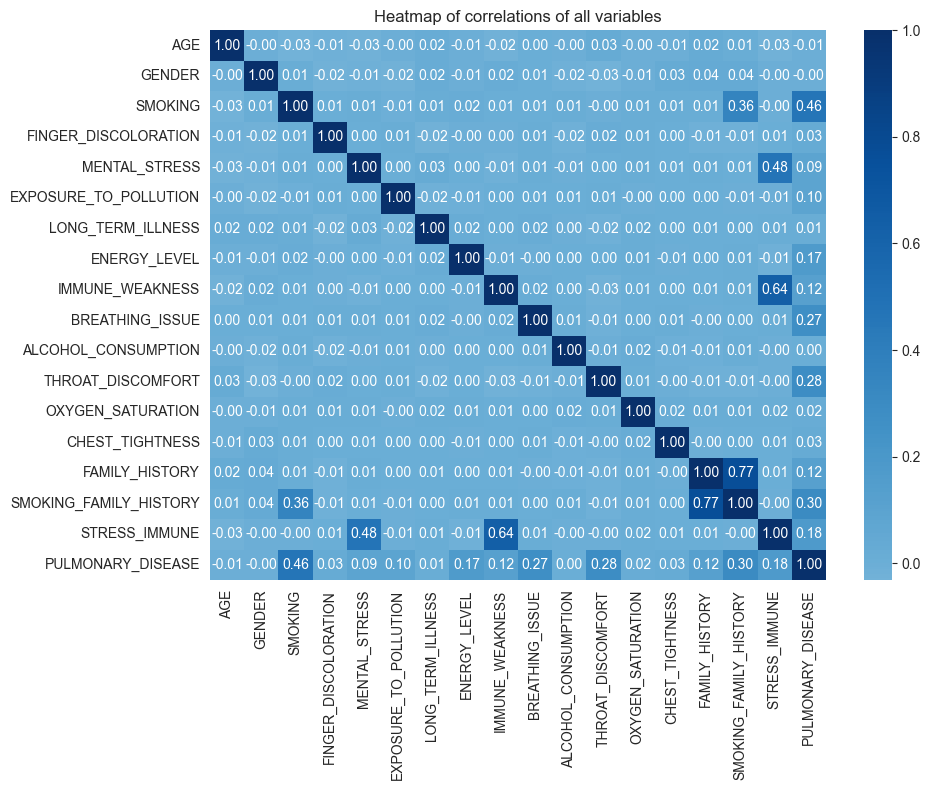

In [19]:
plt.figure(figsize=(10, 8))  

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='Blues',  # escala completa en azul
    center=0,
    fmt='.2f'
)

plt.title('Heatmap of correlations of all variables')
plt.tight_layout()

file_path_plot = os.path.join(eda_dir, "correlation_variable.png")
plt.savefig(file_path_plot)

plt.show()

### Correlación de variables con variable objetivo

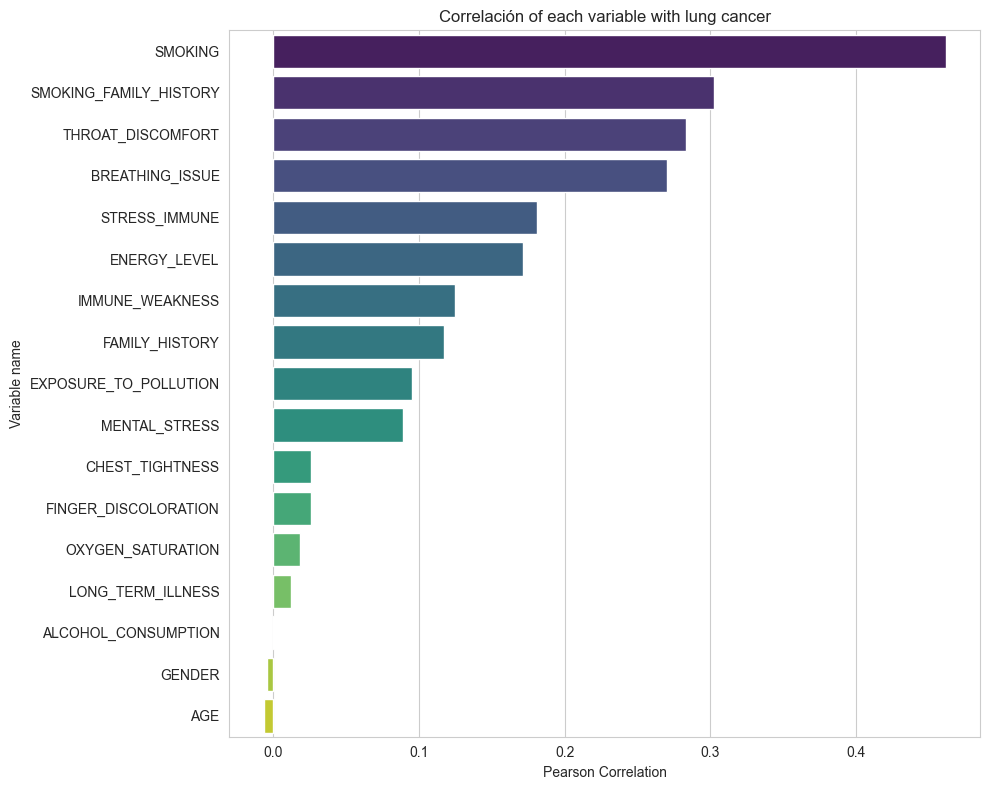

Gráfico guardado en: distribucionDatos\correlation_with_lung_cancer.png


In [20]:
# Calcular correlación con el objetivo y ordenar
corr_target = df.corr()[target].drop(target).sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x=corr_target.values, y=corr_target.index, palette='viridis')
plt.title('Correlación of each variable with lung cancer')
plt.xlabel('Pearson Correlation')
plt.ylabel('Variable name')
plt.tight_layout()
file_path_plot = os.path.join(eda_dir, "correlation_with_lung_cancer.png")
plt.savefig(file_path_plot)

plt.show()
print(f"Gráfico guardado en: {file_path_plot}")

### División entrenamiento/prueba

In [21]:
X = df.drop(columns=[target]) # Características
y = df[target]                # Variable objetivo

# Entrenamiento/prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]} | Prueba: {X_test.shape[0]}")

Entrenamiento: 4000 | Prueba: 1000


## Ingeniería de características avanzada

### Eliminar columnas con varianza muy baja
No se elimina ninguna debido a que no hay varianzas menor a 0.01

In [22]:
selector_var = VarianceThreshold(threshold=0.01)

selector_var.fit(X_train)

cols_keep = X_train.columns[selector_var.get_support()]

X_train = X_train[cols_keep].copy()
X_test = X_test[cols_keep].copy()

print(f"Columnas conservadas: {len(cols_keep)}")
print(f"Shape Train: {X_train.shape}")
print(f"Shape Test: {X_test.shape}")

Columnas conservadas: 17
Shape Train: (4000, 17)
Shape Test: (1000, 17)


### Importancia de características con Random Forest

In [23]:
rf_imp = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_imp.fit(X_train, y_train)

importancias = pd.Series(
    rf_imp.feature_importances_,
    index=X_train.columns
)

top5 = importancias.nlargest(5).index.tolist()

print("Top 5 características:", top5)

Top 5 características: ['SMOKING', 'ENERGY_LEVEL', 'THROAT_DISCOMFORT', 'BREATHING_ISSUE', 'OXYGEN_SATURATION']


### Crear interacciones multiplicativas

In [24]:
for dataset in [X_train, X_test]:

    for i in range(len(top5)):
        for j in range(i + 1, len(top5)):

            dataset[f"{top5[i]}_x_{top5[j]}"] = (
                dataset[top5[i]] *
                dataset[top5[j]]
            )
print(f"Interacciones añadidas: {len(top5)*(len(top5)-1)//2}")
print(f"Nuevo tamaño Train: {X_train.shape}")
print(f"Nuevo tamaño Test: {X_test.shape}")

Interacciones añadidas: 10
Nuevo tamaño Train: (4000, 27)
Nuevo tamaño Test: (1000, 27)


## Entrenamiento de modelos predictivos

### Escalado

In [25]:
continuous_cols = ["ENERGY_LEVEL", "OXYGEN_SATURATION"]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(
    X_train[continuous_cols]
)

X_test_scaled[continuous_cols] = scaler.transform(
    X_test[continuous_cols]
)

### Oversampling y validación cruzada estratificada

In [26]:
# Aumento de datos con SMOTE al conjunto de entrenamiento (oversampling)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(f"Tamaño original de entrenamiento: {X_train.shape[0]}")
print(f"Tamaño alterado con SMOTE de entrenamiento: {X_train_resampled.shape[0]}")
print(f"Distribución de valors en variable objetivo: {pd.Series(y_train_resampled).value_counts(normalize=True)}")

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

Tamaño original de entrenamiento: 4000
Tamaño alterado con SMOTE de entrenamiento: 4740
Distribución de valors en variable objetivo: PULMONARY_DISEASE
0    0.5
1    0.5
Name: proportion, dtype: float64


## Definición de modelos

In [27]:
# Diccionario que guarda el modelo de ML y los hiperparámetros a probar de cada modelo

models_params = {
  'LogisticRegression': {
    'model': LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced'),
    'params': {
      'C': [0.01, 0.1, 1, 10, 100], 
      'solver': ['lbfgs']
    }
  },
  'RandomForest': {
    'model': RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    'params': {
      'n_estimators': [100, 200, 300],
      'max_depth': [5, 10, 20, None],
      'min_samples_split': [2, 5, 10],
      'min_samples_leaf': [1, 2, 4]
    }
  },
  'SVM_RBF': { 
    'model': SVC(probability=True, random_state=42, class_weight='balanced'),
    'params': {
      'C': [0.1, 1, 10, 100],
      'gamma': ['scale', 'auto', 0.1],
      'kernel': ['rbf']
    }
   },
  'KNN': {
    'model': KNeighborsClassifier(),
    'params': {
      'n_neighbors': [3, 5, 7, 9, 11, 15],
      'weights': ['uniform', 'distance'],
      'p': [1, 2]
    }
  },
  'GradientBoosting': {
    'model': GradientBoostingClassifier(random_state=42),
    'params': {
      'n_estimators': [100, 200, 300],
      'learning_rate': [0.01, 0.05, 0.1, 0.2],
      'max_depth': [3, 5, 7],
      'subsample': [0.8, 1.0]
    }
  },
  'CatBoost': {
    'model': CatBoostClassifier(verbose=0, random_state=42, auto_class_weights='Balanced'),
    'params': {
      'iterations': [100, 200, 300],
      'depth': [4, 6, 8, 10],
      'learning_rate': [0.01, 0.05, 0.1],
      'l2_leaf_reg': [1, 3, 5]
    }
  }
}

### Optimización de XGBoost con Optuna

In [28]:
best_models = {}

def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 3),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 2),
        'random_state': 42,
        'eval_metric': 'logloss',
        'use_label_encoder': False,
        'early_stopping_rounds': 10
    }

    auc_scores = []

    for train_idx, val_idx in cv.split(X_train_scaled, y_train):

        # Fold de entrenamiento y validación
        X_tr = X_train_scaled.iloc[train_idx]
        X_val = X_train_scaled.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        # SMOTE SOLO en el fold de entrenamiento
        smote = SMOTE(random_state=42)
        X_tr_resampled, y_tr_resampled = smote.fit_resample(X_tr, y_tr)

        model = XGBClassifier(**params)

        model.fit(
            X_tr_resampled,
            y_tr_resampled,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        y_proba = model.predict_proba(X_val)[:, 1]
        auc_scores.append(roc_auc_score(y_val, y_proba))

    return np.mean(auc_scores)


print("\nOptimizando XGBoost con Optuna...")

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(
    objective,
    n_trials=20,
    show_progress_bar=True
)

best_xgb_params = study.best_params

print("Mejores hiperparámetros para XGBoost:", best_xgb_params)

# ===========================
# Entrenamiento final
# ===========================

smote = SMOTE(random_state=42)
X_train_final, y_train_final = smote.fit_resample(
    X_train_scaled,
    y_train
)

xgb_best = XGBClassifier(
    **best_xgb_params,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)

xgb_best.fit(
    X_train_final,
    y_train_final
)

best_models["XGBoost"] = xgb_best

[I 2026-07-04 20:31:26,878] A new study created in memory with name: no-name-e416eb3d-8491-4499-8733-e64d5fb23a6d



Optimizando XGBoost con Optuna...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-07-04 20:31:27,248] Trial 0 finished with value: 0.9224017026706014 and parameters: {'n_estimators': 212, 'max_depth': 8, 'learning_rate': 0.07441632389160634, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.46798356100860794, 'reg_alpha': 0.11616722433639892, 'reg_lambda': 1.7323522915498704}. Best is trial 0 with value: 0.9224017026706014.
[I 2026-07-04 20:31:28,459] Trial 1 finished with value: 0.9221241582950405 and parameters: {'n_estimators': 280, 'max_depth': 7, 'learning_rate': 0.005394455304087533, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9329770563201687, 'gamma': 0.6370173320348285, 'reg_alpha': 0.36364993441420124, 'reg_lambda': 0.36680901970686763}. Best is trial 0 with value: 0.9224017026706014.
[I 2026-07-04 20:31:29,074] Trial 2 finished with value: 0.922011441736636 and parameters: {'n_estimators': 191, 'max_depth': 6, 'learning_rate': 0.02460208061014162, 'subsample': 0.7164916560792167, 'colsample_bytree': 0.8

### Optimización de los otros modelos con RandomizedSearchCV

In [29]:
for name, mp in models_params.items():

    print(f"\nOptimizando {name} con RandomizedSearchCV...")

    pipeline = Pipeline([
        ("smote", SMOTE(random_state=42)),
        ("model", mp["model"])
    ])

    param_dist = {
        f"model__{k}": v
        for k, v in mp["params"].items()
    }

    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_dist,
        n_iter=15,
        cv=cv,
        scoring="roc_auc",
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(X_train_scaled, y_train)

    print(f"Mejores parámetros para {name}:")
    print(random_search.best_params_)

    best_models[name] = random_search.best_estimator_


Optimizando LogisticRegression con RandomizedSearchCV...
Mejores parámetros para LogisticRegression:
{'model__solver': 'lbfgs', 'model__C': 0.1}

Optimizando RandomForest con RandomizedSearchCV...
Mejores parámetros para RandomForest:
{'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_depth': 10}

Optimizando SVM_RBF con RandomizedSearchCV...
Mejores parámetros para SVM_RBF:
{'model__kernel': 'rbf', 'model__gamma': 'scale', 'model__C': 10}

Optimizando KNN con RandomizedSearchCV...
Mejores parámetros para KNN:
{'model__weights': 'distance', 'model__p': 1, 'model__n_neighbors': 15}

Optimizando GradientBoosting con RandomizedSearchCV...
Mejores parámetros para GradientBoosting:
{'model__subsample': 1.0, 'model__n_estimators': 200, 'model__max_depth': 5, 'model__learning_rate': 0.01}

Optimizando CatBoost con RandomizedSearchCV...
Mejores parámetros para CatBoost:
{'model__learning_rate': 0.01, 'model__l2_leaf_reg': 1, 'model__iteration

### Evaluación en test

In [30]:
# Función para evaluar un modelo ya entrenado en test
def evaluate_model(model, X_test, y_test, model_name):

    # Predicción de clases
    y_pred = model.predict(X_test)

    # Probabilidades
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_proba)
    }

    return metrics, y_proba

results = []
probas_dict = {}

for name, model in best_models.items():
  metrics, y_proba = evaluate_model(model, X_test_scaled, y_test, name)
  results.append(metrics)
  probas_dict[name] = y_proba

results_df = pd.DataFrame(results).set_index('Model')
results_df = results_df.sort_values('AUC', ascending=False)
print("\nResultados finales:\n", results_df.round(4))

# Guardar en carpeta resultadosML
file_path = os.path.join(output_dir, "models_results.csv")
results_df.to_csv(file_path, index=True)
print(f"\nArchivo guardado en: {file_path}")


Resultados finales:
                     Accuracy  Precision  Recall      F1     AUC
Model                                                          
XGBoost                0.894     0.8525  0.8943  0.8729  0.9190
CatBoost               0.890     0.8414  0.8993  0.8694  0.9187
LogisticRegression     0.852     0.7859  0.8747  0.8279  0.9168
RandomForest           0.882     0.8322  0.8894  0.8599  0.9132
GradientBoosting       0.886     0.8383  0.8919  0.8643  0.9128
SVM_RBF                0.745     0.6392  0.8575  0.7324  0.8700
KNN                    0.796     0.7261  0.8010  0.7617  0.8598

Archivo guardado en: resultadosML\models_results.csv


## Markdown

### Gráfico de barras comparativo

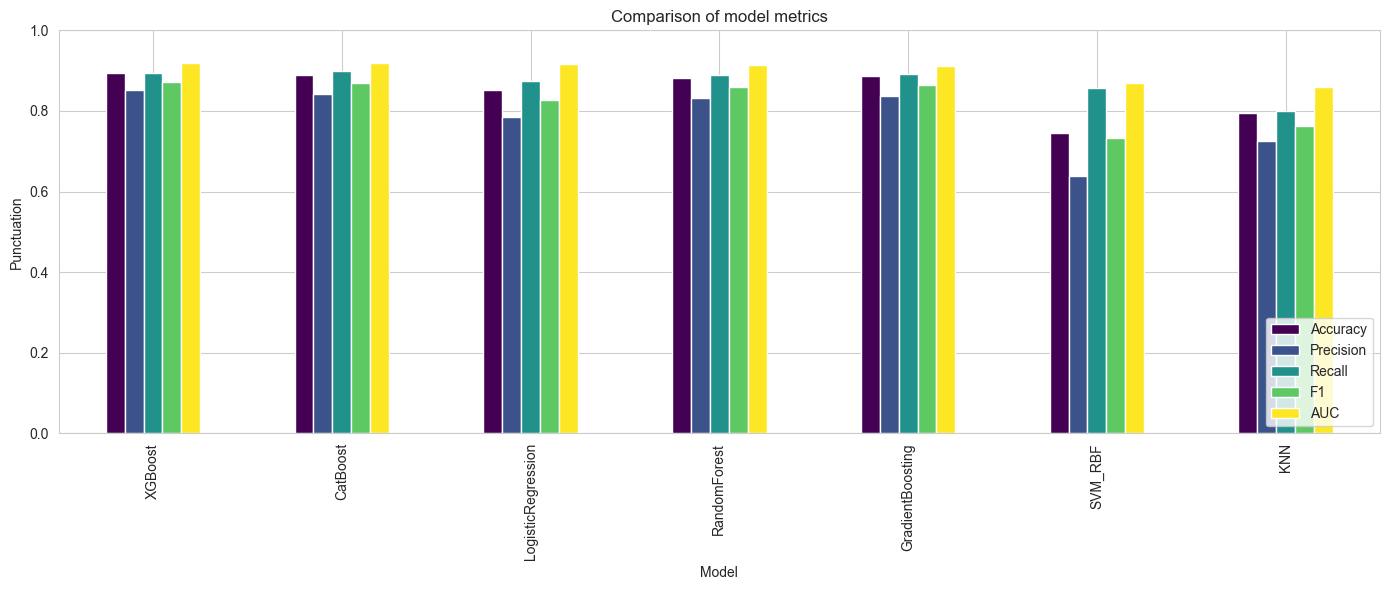

Gráfico guardado en: resultadosML\comparative_bars_models.png


In [31]:
# Métricas a graficar
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']

# Gráfico de barras
results_df[metrics_to_plot].plot(kind='bar', figsize=(14, 6), colormap='viridis')

plt.title('Comparison of model metrics')
plt.ylabel('Punctuation')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()

file_path_plot = os.path.join(output_dir, "comparative_bars_models.png")
plt.savefig(file_path_plot)

plt.show()
print(f"Gráfico guardado en: {file_path_plot}")

### Matrices de confusión para cada modelo

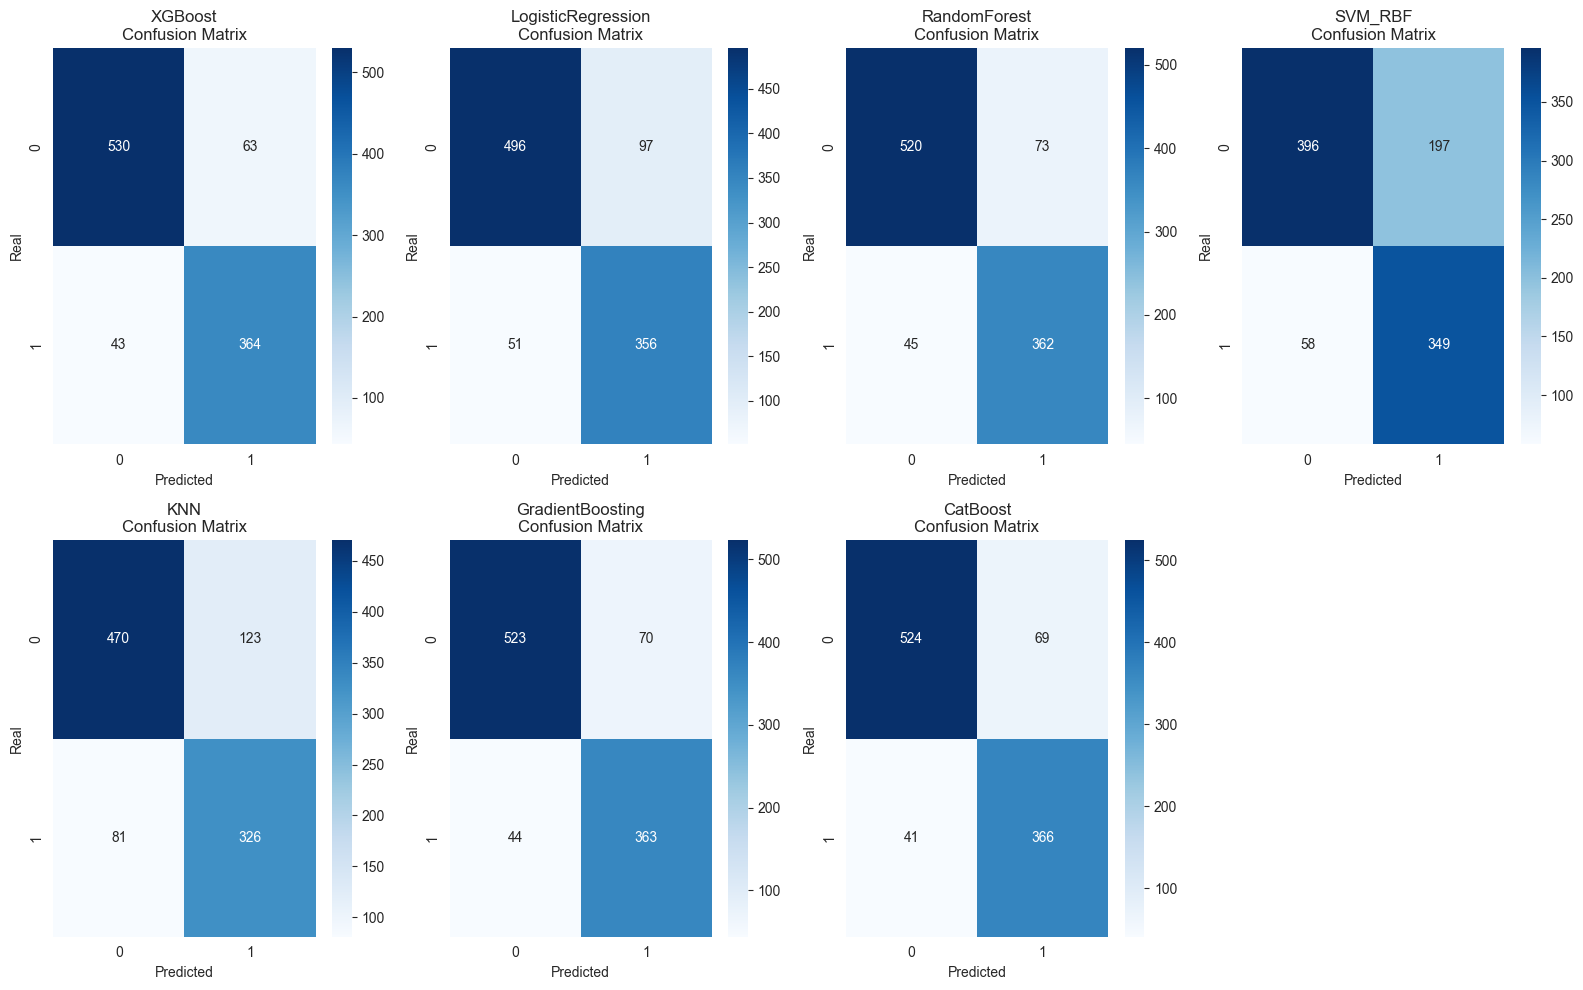

Gráfico guardado en: resultadosML\confusion_matrix.png


In [32]:
fig, axes = plt.subplots(2, 4, figsize=(16,10))
axes = axes.flatten()
for idx, (name, model) in enumerate(best_models.items()):
  y_pred = model.predict(X_test_scaled)
  cm = confusion_matrix(y_test, y_pred)
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
  axes[idx].set_title(f'{name}\nConfusion Matrix')
  axes[idx].set_xlabel('Predicted')
  axes[idx].set_ylabel('Real')

# Ocultar último subplot
if len(best_models) < 8:
  axes[-1].axis('off')
plt.tight_layout()
file_path_plot = os.path.join(output_dir, "confusion_matrix.png")
plt.savefig(file_path_plot)

plt.show()
print(f"Gráfico guardado en: {file_path_plot}")

### Curva ROC para cada modelo

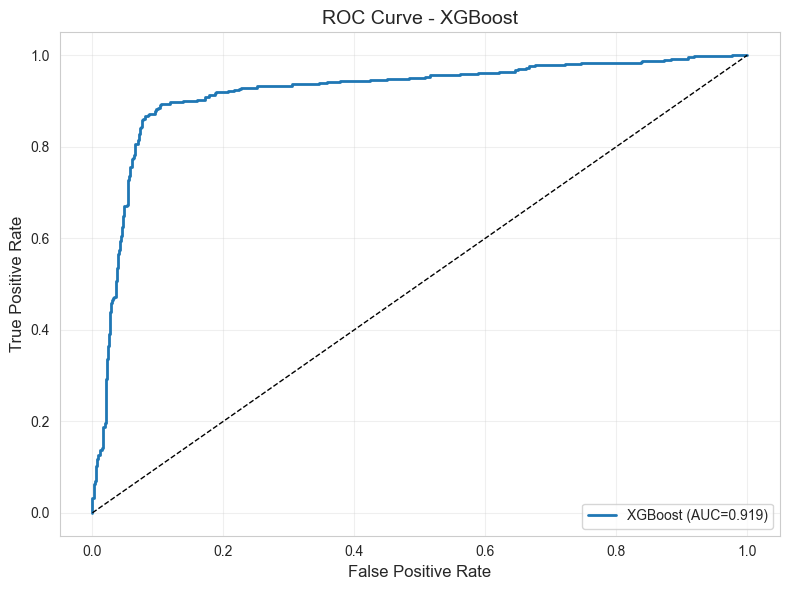

ROC guardada en: resultadosML\roc_XGBoost.png


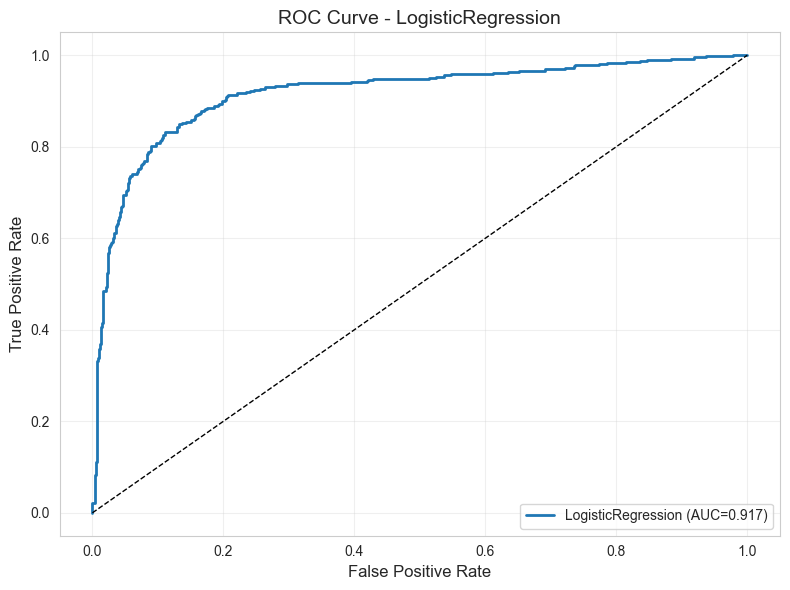

ROC guardada en: resultadosML\roc_LogisticRegression.png


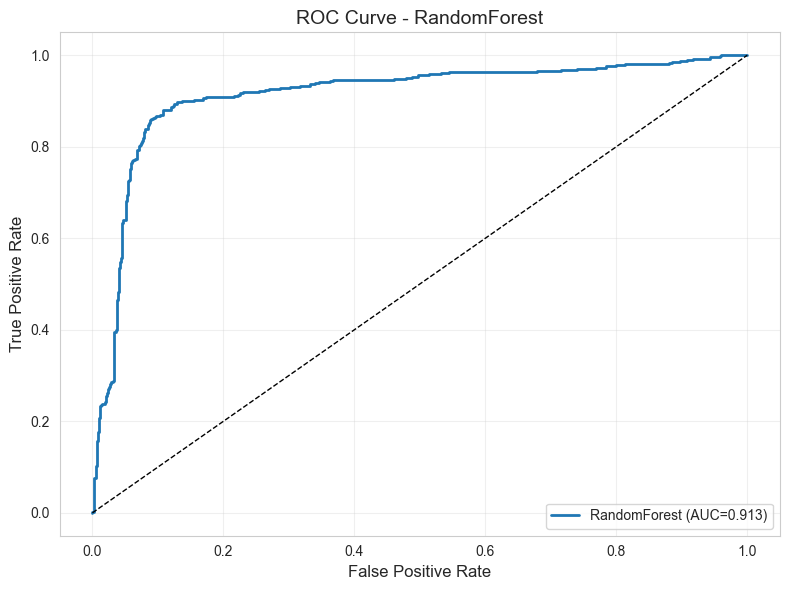

ROC guardada en: resultadosML\roc_RandomForest.png


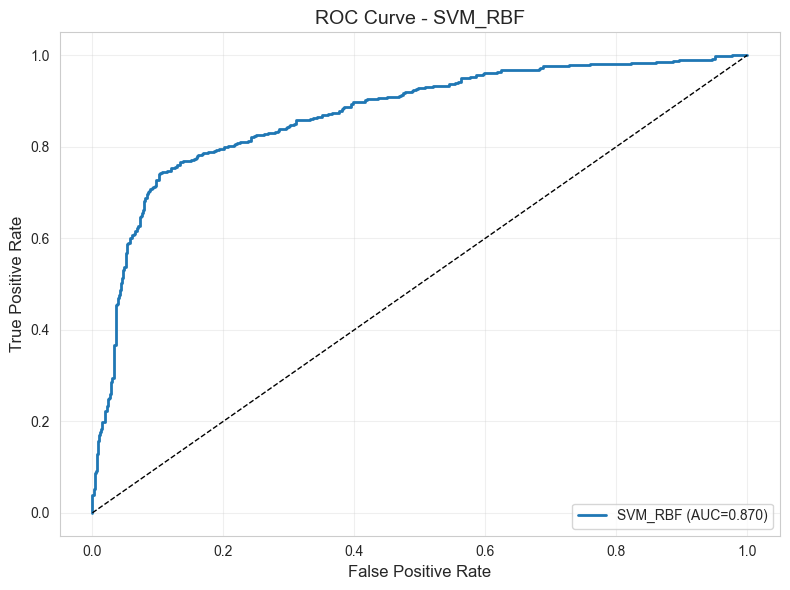

ROC guardada en: resultadosML\roc_SVM_RBF.png


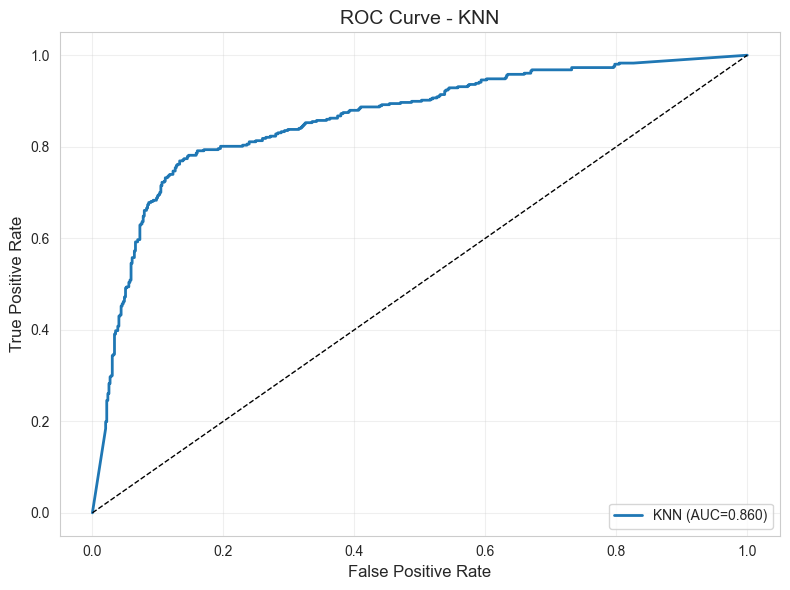

ROC guardada en: resultadosML\roc_KNN.png


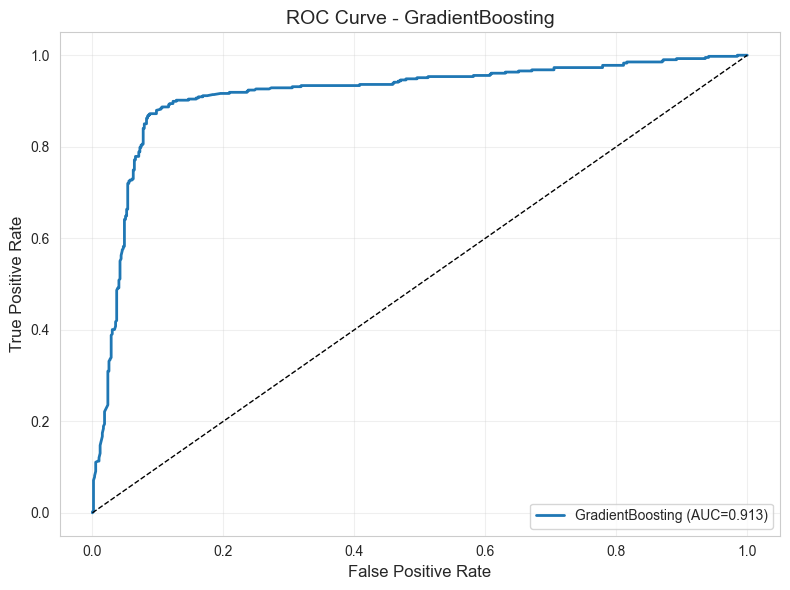

ROC guardada en: resultadosML\roc_GradientBoosting.png


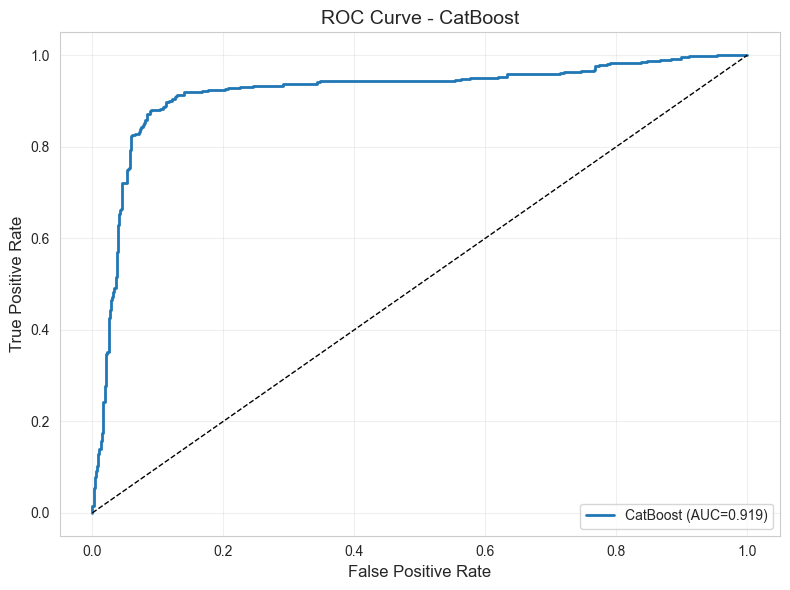

ROC guardada en: resultadosML\roc_CatBoost.png

Curvas ROC guardadas en la carpeta 'resultadosML/'


In [33]:
for name, model in best_models.items():
    plt.figure(figsize=(8, 6))

    try:
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    except:
        y_proba = model.decision_function(X_test_scaled)

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curve - {name}', fontsize=14)
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()

    # Guardar directamente en resultadosML
    file_path_roc = os.path.join(output_dir, f"roc_{name}.png")
    plt.savefig(file_path_roc, dpi=150)

    plt.show()
    plt.close()

    print(f"ROC guardada en: {file_path_roc}")

print("\nCurvas ROC guardadas en la carpeta 'resultadosML/'")

## Seleción del mejor modelo

In [34]:
best_model_name = results_df.sort_values(["Recall", "AUC"],ascending=False).index[0]
best_model = best_models[best_model_name]

print(f"\nMejor modelo seleccionado: {best_model_name}")
print(f"Recall: {results_df.loc[best_model_name, 'Recall']:.4f}, "
      f"AUC: {results_df.loc[best_model_name, 'AUC']:.4f}")


Mejor modelo seleccionado: CatBoost
Recall: 0.8993, AUC: 0.9187


### XAI con SHAP


Generando explicaciones SHAP para el mejor modelo...
Rango SHAP: -1.2118385119998856 0.9999090685213428
Media absoluta (primeras 5): [0.03969941 0.01418293 0.01974444 0.01556935 0.00941546]


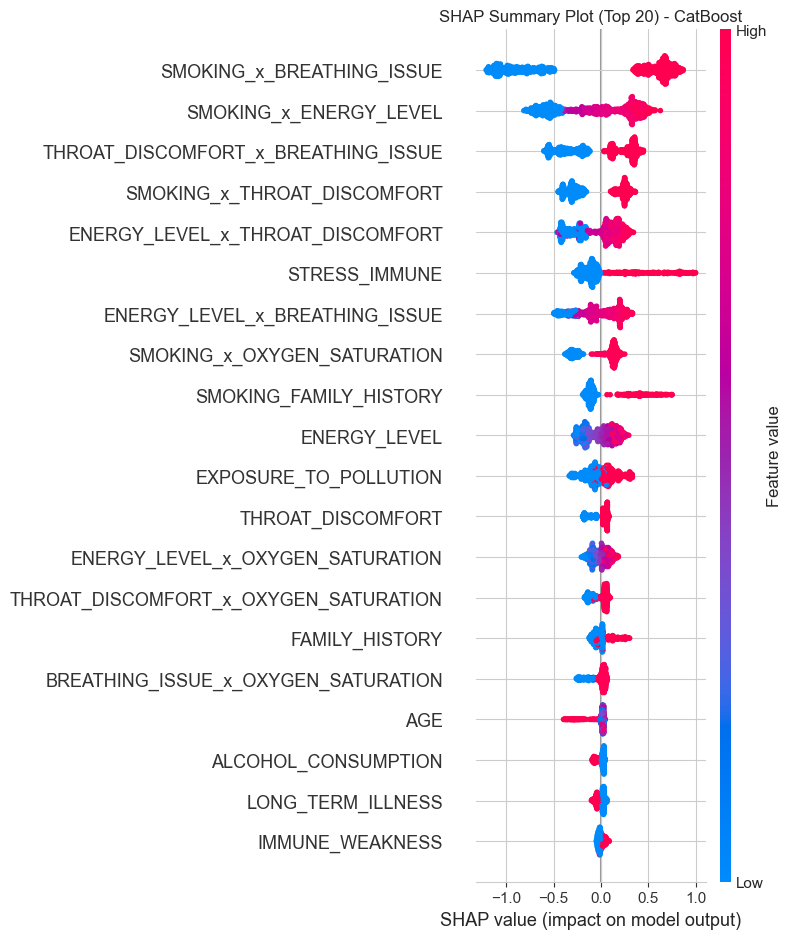

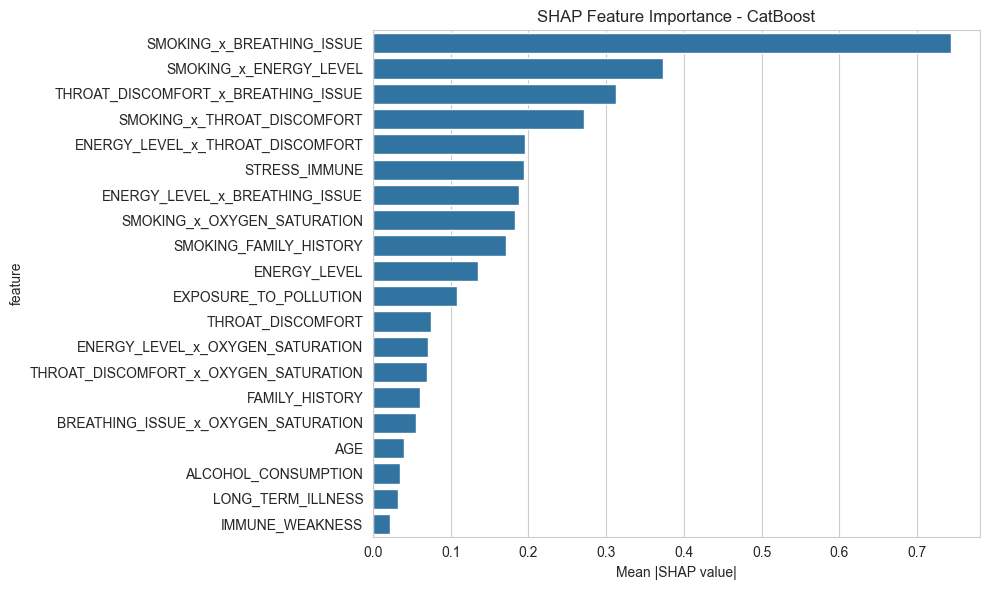

In [35]:
print("\nGenerando explicaciones SHAP para el mejor modelo...")

X_test_shap = X_test_scaled.copy()

# ==========================================================
# Obtener el modelo real si viene dentro de un Pipeline
# ==========================================================
if hasattr(best_model, "named_steps"):
    model_for_shap = best_model.named_steps["model"]
else:
    model_for_shap = best_model


# ==========================================================
# Selección del explicador SHAP
# ==========================================================
if isinstance(model_for_shap, (RandomForestClassifier,
                               GradientBoostingClassifier,
                               CatBoostClassifier,
                               XGBClassifier)):

    explainer = shap.TreeExplainer(model_for_shap)
    shap_values = explainer.shap_values(X_test_shap)

    if isinstance(shap_values, list):
        shap_values = shap_values[1]

elif isinstance(model_for_shap, LogisticRegression):

    background = shap.sample(
        X_train_scaled,
        100,
        random_state=42
    )

    explainer = shap.LinearExplainer(model_for_shap,background)
    shap_values = explainer.shap_values(X_test_shap)

    if isinstance(shap_values, list):
        shap_values = shap_values[1]

else:

    background = shap.sample(
        X_train_scaled,
        100,
        random_state=42
    )

    explainer = shap.KernelExplainer(
        model_for_shap.predict_proba,
        background
    )

    shap_values = explainer.shap_values(X_test_shap)

    if isinstance(shap_values, list):
        shap_values = shap_values[1]

# ==========================================================
# Top 20 variables más importantes
# ==========================================================
mean_abs_shap = np.abs(shap_values).mean(axis=0)

print("Rango SHAP:", shap_values.min(), shap_values.max())
print("Media absoluta (primeras 5):", mean_abs_shap[:5])

top_indices = np.argsort(mean_abs_shap)[-20:]

top_feature_names = X_test_shap.columns[top_indices]

shap_values_top = shap_values[:, top_indices]

X_test_top = X_test_shap.iloc[:, top_indices]


# ==========================================================
# SHAP Summary Plot
# ==========================================================
plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values_top,
    X_test_top,
    feature_names=top_feature_names,
    show=False
)

plt.title(f"SHAP Summary Plot (Top 20) - {best_model_name}")

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "shap_summary_top20.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==========================================================
# Importancia global
# ==========================================================
shap_importance = (
    pd.DataFrame({
        "feature": X_test_shap.columns,
        "mean_abs_shap": mean_abs_shap
    })
    .sort_values("mean_abs_shap", ascending=False)
    .head(20)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=shap_importance,
    y="feature",
    x="mean_abs_shap",
    color="#1f77b4"
)

plt.title(f"SHAP Feature Importance - {best_model_name}")

plt.xlabel("Mean |SHAP value|")

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "shap_importance_bar.png"),
    dpi=300
)

plt.show()

El análisis SHAP evidencia que las variables más influyentes en la predicción corresponden principalmente a interacciones entre factores clínicos y conductuales, destacando la combinación de tabaquismo y saturación de oxígeno. Asimismo, se observa que variables individuales presentan menor impacto en comparación con sus interacciones, lo cual sugiere que el modelo captura relaciones no lineales complejas entre los predictores.

## Exportación de mejor modelo

### Scaler

In [36]:
scaler_final = StandardScaler()

scaler_final.fit(
    X_train[continuous_cols]
)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


### Calcular umbral óptimo

In [37]:
# ==========================================
# Calcular umbral óptimo
# ==========================================

if hasattr(best_model, "predict_proba"):
    y_proba_val = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    scores = best_model.decision_function(X_test_scaled)

    # Normalizar a [0,1] para evaluar umbrales
    y_proba_val = (scores - scores.min()) / (scores.max() - scores.min())

thresholds = np.linspace(0.10, 0.90, 50)

best_threshold = 0.50
best_recall = -1

for th in thresholds:

    y_pred_th = (y_proba_val >= th).astype(int)

    rec = recall_score(y_test, y_pred_th)

    if rec > best_recall:
        best_recall = rec
        best_threshold = th

print(
    f"\nUmbral óptimo: {best_threshold:.3f} "
    f"(Recall={best_recall:.3f})"
)


Umbral óptimo: 0.100 (Recall=0.961)


### Guardar modelo y scaler

In [38]:
joblib.dump(best_model, os.path.join(export_dir, "model.joblib"))
joblib.dump(scaler_final, os.path.join(export_dir, "scaler.joblib"))

['exported_best_model\\scaler.joblib']

### Guardar lista de columnas

In [39]:
feature_names = X_train_scaled.columns.tolist()
with open(os.path.join(export_dir, "feature_names.json"), "w") as f:
    json.dump(feature_names, f, indent=2)

### Guardar top5 features

In [40]:
top5 = importancias.nlargest(5).index.tolist() 
with open(os.path.join(export_dir, "top5_features.json"), "w") as f:
    json.dump(top5, f, indent=2)

### Guardar metadatos

In [41]:
# ==========================================
# Probabilidades para generar metadatos
# ==========================================

if hasattr(best_model, "predict_proba"):
    y_proba_test = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    scores = best_model.decision_function(X_test_scaled)
    y_proba_test = (scores - scores.min()) / (scores.max() - scores.min())

thresholds = np.linspace(0.1, 0.9, 50)

best_threshold = 0.5
best_recall = -1

for th in thresholds:

    y_pred_th = (y_proba_test >= th).astype(int)

    rec = recall_score(y_test, y_pred_th)

    if rec > best_recall:
        best_recall = rec
        best_threshold = th


# ==========================================
# Métricas con el umbral óptimo
# ==========================================

y_pred_opt = (y_proba_test >= best_threshold).astype(int)

accuracy_opt = accuracy_score(y_test, y_pred_opt)
precision_opt = precision_score(y_test, y_pred_opt)
recall_opt = recall_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test, y_pred_opt)
auc_opt = roc_auc_score(y_test, y_proba_test)

print("\n=== Métricas con umbral óptimo ===")
print(f"Threshold : {best_threshold:.3f}")
print(f"Accuracy  : {accuracy_opt:.4f}")
print(f"Precision : {precision_opt:.4f}")
print(f"Recall    : {recall_opt:.4f}")
print(f"F1        : {f1_opt:.4f}")
print(f"AUC       : {auc_opt:.4f}")

metadata = {
    "model_name": best_model_name,

    "threshold": float(best_threshold),

    # Métricas con threshold = 0.5
    "accuracy": float(results_df.loc[best_model_name, "Accuracy"]),
    "precision": float(results_df.loc[best_model_name, "Precision"]),
    "recall": float(results_df.loc[best_model_name, "Recall"]),
    "f1": float(results_df.loc[best_model_name, "F1"]),
    "auc": float(results_df.loc[best_model_name, "AUC"]),

    # Métricas usando el threshold óptimo
    "accuracy_opt": float(accuracy_opt),
    "precision_opt": float(precision_opt),
    "recall_opt": float(recall_opt),
    "f1_opt": float(f1_opt),
    "auc_opt": float(auc_opt),

    "training_date": pd.Timestamp.now().isoformat(),
    "features_count": len(feature_names),
    "scaler_mean": scaler_final.mean_.tolist(),
    "scaler_scale": scaler_final.scale_.tolist(),
    "top5_features": top5
}

with open(os.path.join(export_dir, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)


=== Métricas con umbral óptimo ===
Threshold : 0.100
Accuracy  : 0.5600
Precision : 0.4798
Recall    : 0.9607
F1        : 0.6399
AUC       : 0.9187
